In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

# PARTE 1

# Imprimimos los primeros datos y vemos los tipos de datos

In [ ]:
display(df.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [ ]:
print(df.dtypes)

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


# Identificación, reemplazo y verificación

In [ ]:
nulos = df['horsepower'].isnull().sum()
print(f"\nValores nulos encontrados en 'horsepower' antes: {nulos}")


Valores nulos encontrados en 'horsepower' antes: 6


In [ ]:
mediana = df['horsepower'].median()
df['horsepower'] = df['horsepower'].fillna(mediana)

In [ ]:
reemplazo = df['horsepower'].isnull().sum()
print(f"Valores nulos encontrados en 'horsepower' después del reemplazo: {reemplazo}")

Valores nulos encontrados en 'horsepower' después del reemplazo: 0


# Nueva columna ***relacion_peso_potencia***

In [ ]:
df['relacion_peso_potencia'] = df['weight'] / df['horsepower']

display(df.head())

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name,relacion_peso_potencia
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu,26.953846
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320,22.381818
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite,22.906667
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst,22.886667
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino,24.635714


# PARTE 2

# Histograma

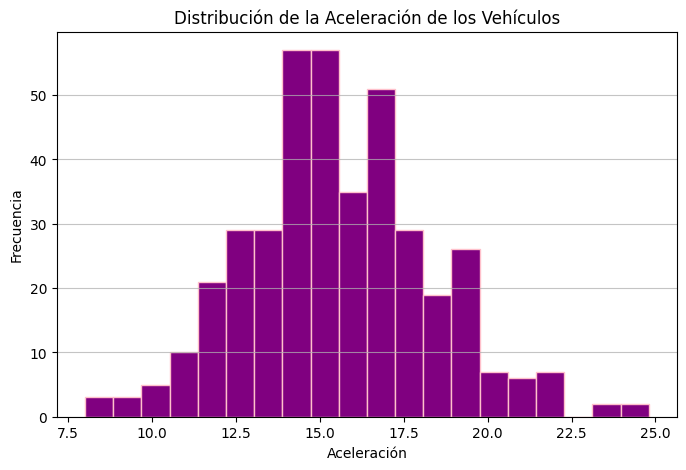

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df['acceleration'], bins=20, color='purple', edgecolor='pink')
plt.title('Distribución de la Aceleración de los Vehículos')
plt.xlabel('Aceleración')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

**Hola, esta celda vas a borrarla**

Explicación:


> plt.figure(figsize=(8, 5))

¿Qué significa? Estamos asignando el tamaño del gráfico, siendo 8 pulgadas de ancho por 5 pulgadas de alto, **estos valores PUEDE CAMBIARSE**.



> plt.hist(df['acceleration'], bins=20, color='purple', edgecolor='pink')

¿Qué significa? Estamos creando un histograma, al llamar a la columna df['acceleration'] estamos diciendo que queremos que se cree con base a esa columna, los bins son la cantidad de rectángulos que se van a generar, el color es el color que se va a pintar los rectángulos y edgecolor es el borde de los rectángulos. **TODOS ESTOS VALORES PUEDEN CAMBIARSE, puedes jugar con la cantidad de rectángulos o los colores, pero no muevas df['acceleration']**




> plt.grid(axis='y', alpha=0.75)

¿Qué significa? Con axis = 'y' estamos pidiendo que solo se generen líneas horizontales, mientras que alpha = 0.75, estamos dándole intensidad al color de la línea, es su trasparencia, mientras más cerca a 1 esté el color será más sólido. **PUEDE CAMBIARSE O SIMPLEMENTE PUEDES BORRAR ESTA LÍNEA.**




> plt.show()


¿Qué significa? Bueno, con esto simplemente hacemos que el gráfico sea visible

# Gráfico de dispersión (Scatter)

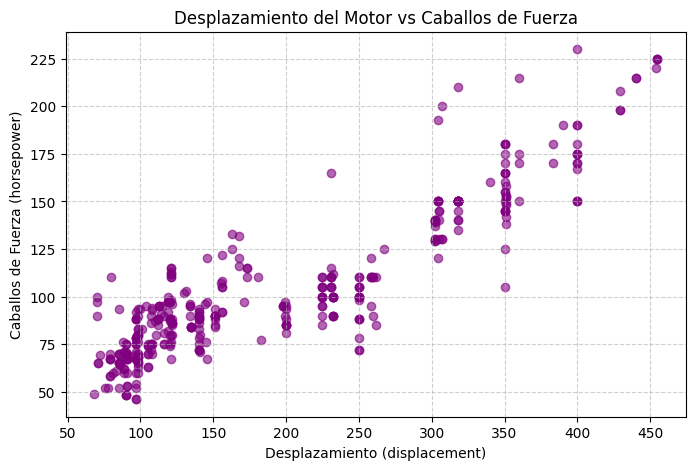

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(df['displacement'], df['horsepower'], alpha=0.6, color='purple')
plt.title('Desplazamiento del Motor vs Caballos de Fuerza')
plt.xlabel('Desplazamiento (displacement)')
plt.ylabel('Caballos de Fuerza (horsepower)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Hola, esta celda vas a borrarla**

Explicación:


> plt.figure(figsize=(8, 5))

¿Qué significa? Estamos asignando el tamaño del gráfico, siendo 8 pulgadas de ancho por 5 pulgadas de alto, **estos valores PUEDE CAMBIARSE**.



> plt.scatter(df['displacement'], df['horsepower'], alpha=0.6, color='purple')

¿Qué significa? Estamos creando un gráfico de dispersión o en inglés SCATTER, al llamar a la columna df['displacement'] y df['horsepower'], estamos diciendo que queremos que se cree con base a esas dos columnas, con alpha = 0.6 jugamos con la transparencia de los puntitos, mientras más cerca a 1 más intenso se verán, el color es el color que se va a pintar los puntos. **TODOS ESTOS VALORES PUEDEN CAMBIARSE, puedes jugar con los colores o la intensidad de delineado, pero no muevas df['displacement'] ni df['horsepower']**




> plt.grid(True, linestyle='--', alpha=0.6)

¿Qué significa? Con true estamos diciendo que queremos que se genere una cuadrícula, mientras que linestyle = '--' significa el tipo de línea que se va a dibujar. Con alpha = 0.6 estamos dándole intensidad al color de las líneas, es decir, su trasparencia, mientras más cerca a 1 esté el color será más sólido. **PUEDE CAMBIARSE O SIMPLEMENTE PUEDES BORRAR ESTA LÍNEA.**


> plt.show()

¿Qué significa? Bueno, con esto simplemente hacemos que el gráfico sea visible


# Gráfico de barras

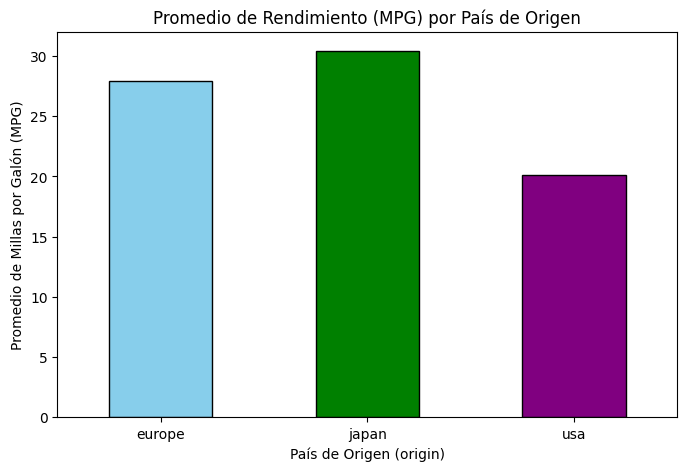

In [ ]:
promedio_mpgyorigen = df.groupby('origin')['mpg'].mean()
plt.figure(figsize=(8, 5))
promedio_mpgyorigen.plot(kind='bar', color=['skyblue', 'green', 'purple'], edgecolor='black')
plt.title('Promedio de Rendimiento (MPG) por País de Origen')
plt.xlabel('País de Origen (origin)')
plt.ylabel('Promedio de Millas por Galón (MPG)')
plt.xticks(rotation=0)
plt.show()

**Hola, esta celda vas a borrarla**

Explicación:

> promedio_mpgyorigen = df.groupby('origin')['mpg'].mean()
¿Qué significa? Agrupa todos los autos de tu tabla según su país de origen pero que, de todos los datos de esos autos, solo nos interesa la columna de rendimiento (millas por galón o mpg), finalmente se calcula el promedio de ese rendimiento para cada grupo y almacenamos en la variable promedio_mpgyorigen

> plt.figure(figsize=(8, 5))

¿Qué significa? Estamos asignando el tamaño del gráfico, siendo 8 pulgadas de ancho por 5 pulgadas de alto, **estos valores PUEDE CAMBIARSE**.



> promedio_mpgyorigen.plot(kind='bar', color=['skyblue', 'green', 'purple'], edgecolor='black')

¿Qué significa? Estamos creando un gráfico  partir de la variable que acabamos de crear (promedio_mpgyorigen), con kind = 'bar' decimos que queremos que sean barras verticale, el color es el color que se va a pintar estas barras y edgecolor es el borde que tendrán estas barrsa. **TODOS ESTOS VALORES PUEDEN CAMBIARSE, puedes jugar con los colores, pero no muevas promedio_mpgyorigen. Si quieres que las barras sean horizontales lo reemplazas por kind='barh'**




> plt.xticks(rotation=0)

¿Qué significa? Al poner rotation=0, forzamos a que el texto del eje x (países de origen) se mantenga perfectamente horizontal. **PUEDES BORRAR ESTA LÍNEA SI QUIERES**


> plt.show()

¿Qué significa? Bueno, con esto simplemente hacemos que el gráfico sea visible
